# Coursework Template

## Setup

**Dependencies and imports**

This can take a minute...

In [ ]:
!pip install swig
!pip install rldurham

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # disable CUDA (better on Colab/NCC: choose an environment without GPU)
import torch
import rldurham as rld

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import collections, random

import os
from google.colab import drive

In [ ]:
class ReplayBuffer:
    def __init__(self, obs_dim, act_dim, size):
        self.s = np.zeros((size, obs_dim), dtype=np.float32)
        self.a = np.zeros((size, act_dim), dtype=np.float32)
        self.r = np.zeros((size, 1), dtype=np.float32)
        self.sp = np.zeros((size, obs_dim), dtype=np.float32)
        self.d = np.zeros((size, 1), dtype=np.float32)
        self.ptr = 0
        self.size = 0
        self.max_size = size

    def put(self, s, a, r, sp, done):
        self.s[self.ptr] = s
        self.a[self.ptr] = a
        self.r[self.ptr] = r
        self.sp[self.ptr] = sp
        self.d[self.ptr] = 0.0 if done else 1.0
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.from_numpy(self.s[idx]),
            torch.from_numpy(self.a[idx]),
            torch.from_numpy(self.r[idx]),
            torch.from_numpy(self.sp[idx]),
            torch.from_numpy(self.d[idx]),
        )

In [ ]:
class PolicyNet(nn.Module):
    def __init__(self, learning_rate, act_dim, obs_dim, init_alpha, lr_alpha):
        super(PolicyNet, self).__init__() #부모 클래스(nn.Module)의 초기화도 실행
        latent_dim = 256

        self.net = nn.Sequential(
            nn.Linear(obs_dim, latent_dim),
            nn.LayerNorm(latent_dim),  # 추가
            nn.ReLU(),
            nn.Linear(latent_dim, latent_dim),
            nn.LayerNorm(latent_dim),  # 추가
            nn.ReLU(),
        )

        self.fc_mu = nn.Linear(latent_dim, act_dim)
        self.fc_std = nn.Linear(latent_dim, act_dim)

        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

        self.log_alpha = torch.tensor(np.log(init_alpha))
        self.log_alpha.requires_grad = True
        self.log_alpha_optimizer = optim.Adam([self.log_alpha], lr=lr_alpha)

    def forward(self, x):
        x = self.net(x)
        mu = self.fc_mu(x)
        log_std = self.fc_std(x)
        log_std = torch.clamp(log_std, -20, 2)
        std = torch.exp(log_std)

        dist = Normal(mu, std) #평균이 mu이고 표준편차가 std인 정규분포를 만든다
                               # 각 action 차원마다 정규분포를 하나씩 갖는다

        action = dist.rsample() #각 행동 차원마다 분포에서 값을 하나씩 뽑아 최종 행동 벡터를 만듬.

        log_prob = dist.log_prob(action).sum(dim=-1, keepdim=True)
        real_action = torch.tanh(action)
        correction = torch.log(1 - real_action.pow(2) + 1e-7).sum(dim=-1, keepdim=True)
        real_log_prob = log_prob - correction

        return real_action, real_log_prob

    def train_net(self, q1, q2, mini_batch, target_entropy):
        s, _, _, _, _ = mini_batch # (s, a, r, s_prime, done_mask) 
        a, log_prob = self.forward(s) 
        entropy = -self.log_alpha.exp() * log_prob  #entropy = -alpha * log_prob

        q1_val, q2_val = q1(s,a), q2(s,a) # 두 cirtic 에게 묻기 답은 두개
        q1_q2 = torch.cat([q1_val, q2_val], dim=1)
        min_q = torch.min(q1_q2, 1, keepdim=True)[0]  # 두 크리틱 답중 안좋은답 채택

        loss = -min_q - entropy # for gradient ascent
        self.optimizer.zero_grad() # 초기화
        loss.mean().backward() #  actor 네트워크 안의 각 weight에 대해 이 weight를 조금 바꾸면 loss가 얼마나 변하는가?
        torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
        self.optimizer.step()  # 업데이트

        self.log_alpha_optimizer.zero_grad()
        alpha_loss = -(self.log_alpha.exp() * (log_prob + target_entropy).detach()).mean()
        alpha_loss.backward()
        self.log_alpha_optimizer.step()

    def act_deterministic(self, x):
        x = self.net(x)
        mu = self.fc_mu(x)
        return torch.tanh(mu)

In [ ]:
class QNet(nn.Module): # critics

    def __init__(self, learning_rate, act_dim, obs_dim):
        super(QNet, self).__init__()
        self.fc_s = nn.Linear(obs_dim, 256)
        self.ln_s = nn.LayerNorm(256)
        self.fc_a = nn.Linear(act_dim, 256)
        self.ln_a = nn.LayerNorm(256)
        self.fc_cat = nn.Linear(512, 256)
        self.ln_cat = nn.LayerNorm(256)
        self.fc_out = nn.Linear(256, 1)
        self.optimizer = optim.Adam(self.parameters(), lr=learning_rate)

    def forward(self, x, a):
        h1 = F.relu(self.ln_s(self.fc_s(x)))
        h2 = F.relu(self.ln_a(self.fc_a(a)))
        cat = torch.cat([h1, h2], dim=1)
        q = F.relu(self.ln_cat(self.fc_cat(cat)))
        q = self.fc_out(q)
        return q

    def train_net(self, target, mini_batch):
        s, a, r, s_prime, done = mini_batch
        loss = F.smooth_l1_loss(self.forward(s, a), target) 
                                                    
        self.optimizer.zero_grad()
        loss.mean().backward()
        torch.nn.utils.clip_grad_norm_(self.parameters(), 1.0)
        self.optimizer.step()

    def soft_update(self, net_target, tau):
        for param_target, param in zip(net_target.parameters(), self.parameters()):
            param_target.data.copy_(param_target.data * (1.0 - tau) + param.data * tau)

In [ ]:
class Agent(nn.Module):

    def __init__(self,
                 env,
                 lr_pi = 3e-4,
                 lr_q = 3e-4,
                 lr_alpha = 3e-4, # for automated alpha update


                 init_alpha=0.2,
                 buffer_limit=250_000,
                 gamma=0.99,
                 batch_size=256,
                 tau=0.005,  # for target network soft update
                 target_entropy=None,  # for automated alpha update
                 train_steps=1,
                 ):
        super().__init__()
        self.env = env
        discrete_act, discrete_obs, act_dim, obs_dim = rld.env_info(env, print_out=True)
        self.act_dim = act_dim
        self.obs_dim = obs_dim

       # print(env.action_space)
        #print(env.action_space.low)
       # print(env.action_space.high)
        self.gamma = gamma
        self.batch_size = batch_size
        self.tau = tau
        self.target_entropy = -act_dim

        self.train_steps = train_steps
        self.total_steps = 0
        self.start_steps = 1000
        self.update_every = 1
        self.policy_delay = 1
        self.total_updates = 0

        self.obs_mean = np.zeros(obs_dim)
        self.obs_var  = np.ones(obs_dim)
        self.obs_count = 1e-4

        self.memory = ReplayBuffer(obs_dim, act_dim, buffer_limit)
        self.q1 = QNet(lr_q, act_dim, obs_dim)
        self.q2 = QNet(lr_q, act_dim, obs_dim)
        self.q1_target = QNet(lr_q, act_dim, obs_dim)
        self.q2_target = QNet(lr_q, act_dim, obs_dim)
        self.pi = PolicyNet(lr_pi, act_dim, obs_dim, init_alpha=init_alpha, lr_alpha=lr_alpha)

        self.q1_target.load_state_dict(self.q1.state_dict())
        self.q2_target.load_state_dict(self.q2.state_dict())



    def action(self, s, evaluate=False):
        if self.total_steps < self.start_steps and not evaluate:
            return self.env.action_space.sample()

        with torch.no_grad():
            x = torch.from_numpy(s).float()
            if evaluate:
                a = self.pi.act_deterministic(x)
            else:
                a, _ = self.pi(x)

        return a.numpy()
    def put(self, s, a, r, s_prime, done):
        self.memory.put(s, a, r , s_prime, done) # 원래는 R / 10.0 이였음

    def train(self):
        if self.memory.size > 5000:
            for _ in range(self.train_steps):
                mini_batch = self.memory.sample(self.batch_size)
                td_target = self.calc_target(mini_batch)

                self.q1.train_net(td_target, mini_batch)
                self.q2.train_net(td_target, mini_batch)

                self.total_updates += 1

                if self.total_updates % self.policy_delay == 0:
                    self.pi.train_net(self.q1, self.q2, mini_batch, target_entropy=self.target_entropy)
                    self.q1.soft_update(self.q1_target, tau=self.tau)
                    self.q2.soft_update(self.q2_target, tau=self.tau)

    def calc_target(self, mini_batch):
        s, a, r, s_prime, done = mini_batch

        with torch.no_grad():
            a_prime, log_prob = self.pi(s_prime)
            entropy = -self.pi.log_alpha.exp() * log_prob
            q1_val = self.q1_target(s_prime, a_prime)
            q2_val = self.q2_target(s_prime, a_prime)
            q1_q2 = torch.cat([q1_val, q2_val], dim=1)
            min_q = torch.min(q1_q2, 1, keepdim=True)[0]
            target = r + self.gamma * done * (min_q + entropy)

        return target

    def episode(self):
        done = False
        s, _ = self.env.reset()
        info = {}
        episode_reward = 0.0
        while not done:
            self._update_obs_stats(s)
            s_norm = self._normalize_obs(s)
            a = self.action(s_norm)
            s_prime, r, terminated, truncated, info = self.env.step(a)
            done = terminated or truncated
            s_prime_norm = self._normalize_obs(s_prime)
            episode_reward += r
            self.put(s_norm, a, r, s_prime_norm, done)
            s = s_prime

            self.total_steps += 1
            if self.total_steps % self.update_every == 0:
                self.train()
        info['r_sum'] = episode_reward
        return info

    def _update_obs_stats(self, obs):
        self.obs_count += 1
        delta = obs - self.obs_mean
        self.obs_mean += delta / self.obs_count
        delta2 = obs - self.obs_mean          # 새 mean 기준 delta
        self.obs_var  += delta * delta2

    def _normalize_obs(self, obs):
        std = np.sqrt(self.obs_var / self.obs_count + 1e-8)
        return (obs - self.obs_mean) / std

In [ ]:
drive.mount('/content/drive')

os.makedirs('/content/drive/MyDrive/RL_project', exist_ok=True)

SAVE_PATH = '/content/drive/MyDrive/RL_project/sac_checkpoint.pt'

def save_checkpoint(agent, n_epi, best_reward):
    torch.save({
        'pi': agent.pi.state_dict(),
        'q1': agent.q1.state_dict(),
        'q2': agent.q2.state_dict(),
        'q1_target': agent.q1_target.state_dict(),
        'q2_target': agent.q2_target.state_dict(),
        'n_epi': n_epi,
        'best_reward': best_reward,
        'obs_mean': agent.obs_mean,
        'obs_var': agent.obs_var,
        'obs_count': agent.obs_count,
        'total_steps': agent.total_steps,
        'total_updates': agent.total_updates,
    }, SAVE_PATH)


import glob, shutil, os

def sync_videos_to_drive():
    drive_videos = '/content/drive/MyDrive/RL_project/videos'
    os.makedirs(drive_videos, exist_ok=True)
    for f in glob.glob('/content/**/*.mp4', recursive=True):
        if '/drive/' not in f:
            dst = os.path.join(drive_videos, os.path.basename(f))
            shutil.copy2(f, dst)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


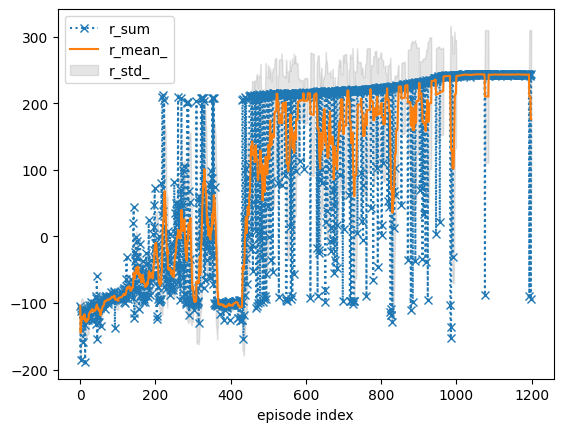

KeyboardInterrupt: 

In [ ]:
# initialise environment
env = rld.make("rldurham/Walker", render_mode="rgb_array")
rld.seed_everything(42, env)

env = rld.Recorder(
    env,
    smoothing=10,                       # track rolling averages (useful for plotting)
    video=True,                         # enable recording videos
    video_folder="videos",              # folder for videos
    video_prefix="fyzr56-agent-video",  # prefix for videos (replace xxxx00 with your username)
    logs=True,                          # keep logs
)

recorder = env
recorder.video = False
tracker = rld.InfoTracker()

# clip negative rewards (known trick in Walker environment)
env = rld.transparent_wrapper(gym.wrappers.ClipReward)(env, min_reward=-10)

# initialise agent
agent = Agent(env)
best_reward = -float('inf')

start_epi = 0
if os.path.exists(SAVE_PATH):
    ckpt = torch.load(SAVE_PATH, weights_only=False)
    agent.pi.load_state_dict(ckpt['pi'])
    agent.q1.load_state_dict(ckpt['q1'])
    agent.q2.load_state_dict(ckpt['q2'])
    agent.q1_target.load_state_dict(ckpt['q1_target'])
    agent.q2_target.load_state_dict(ckpt['q2_target'])
    agent.obs_mean  = ckpt['obs_mean']
    agent.obs_var   = ckpt['obs_var']
    agent.obs_count = ckpt['obs_count']
    start_epi = ckpt['n_epi'] + 1
    best_reward = ckpt['best_reward']
    print(f"Resume from episode {start_epi}")


for n_epi in range(start_epi, 2000):

    recorder.video = (n_epi + 1) % 25 == 0
    info = agent.episode()
    tracker.track(info)
    episode_reward = info.get('r', 0)

    if episode_reward > best_reward:
        best_reward = episode_reward
        torch.save({
            'pi': agent.pi.state_dict(),
            'q1': agent.q1.state_dict(),
            'q2': agent.q2.state_dict(),
            'q1_target': agent.q1_target.state_dict(),
            'q2_target': agent.q2_target.state_dict(),
            'obs_mean': agent.obs_mean,
            'obs_var':  agent.obs_var,
            'obs_count': agent.obs_count,
        }, '/content/drive/MyDrive/RL_project/best_sac_model.pt')
        print(f"[Episode {n_epi}] Best model saved! reward={best_reward:.1f}")

    if (n_epi + 1) % 10 == 0:
        save_checkpoint(agent, n_epi, best_reward)
        tracker.plot(r_mean_=True, r_std_=True, r_sum=dict(linestyle=':', marker='x'))

    if (n_epi + 1) % 25 == 0:
        env.write_log(folder="/content/drive/MyDrive/RL_project", file="fyzr56-agent-log.txt")

        sync_videos_to_drive()

env.write_log(folder="/content/drive/MyDrive/RL_project", file="fyzr56-agent-log.txt")
env.close()
